In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# Import Kaggle Data and Preprocess

In [16]:
player = pd.read_csv('data/baseballdatabank/Master.csv')
batting = pd.read_csv('data/baseballdatabank/Batting.csv')

In [17]:
print(player.columns)
print(batting.columns)

Index(['playerID', 'birthYear', 'birthMonth', 'birthDay', 'birthCountry',
       'birthState', 'birthCity', 'deathYear', 'deathMonth', 'deathDay',
       'deathCountry', 'deathState', 'deathCity', 'nameFirst', 'nameLast',
       'nameGiven', 'weight', 'height', 'bats', 'throws', 'debut', 'finalGame',
       'retroID', 'bbrefID'],
      dtype='object')
Index(['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H',
       '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH',
       'SF', 'GIDP'],
      dtype='object')


| 컬럼         | 의미                                      |
| ---------- | --------------------------------------- |
| `playerID` | 선수 고유 ID (String)                          |
| `yearID`   | 시즌 연도                                   |
| `stint`    | 해당 시즌 중 몇 번째 팀에서 뛰었는지 (1이면 하나의 팀에서만 활동) |
| `teamID`   | 소속 팀 약어 (예: NYA, BOS)                   |
| `lgID`     | 리그 (AL: 아메리칸 리그, NL: 내셔널 리그)            |
| `G`        | Number of Games                                    |
| `AB`       | At Bats: 타석 수 (희생번트, 볼넷 제외)             |
| `R`        | Runs: 득점 수                              |
| `H`        | Hits: 안타 수                              |
| `2B`       | 2루타 수                                   |
| `3B`       | 3루타 수                                   |
| `HR`       | 홈런 수                                    |
| `RBI`      | Runs Batted In: 타점                      |
| `SB`       | Stolen Bases: 도루                        |
| `CS`       | Caught Stealing: 도루 실패                  |
| `BB`       | Base on Balls: 볼넷                       |
| `SO`       | Strikeouts: 삼진                          |
| `IBB`      | Intentional Walks: 고의 사구                |
| `HBP`      | Hit By Pitch: 몸에 맞는 볼                   |
| `SH`       | Sacrifice Hits: 희생번트                    |
| `SF`       | Sacrifice Flies: 희생 플라이                 |
| `GIDP`     | Ground Into Double Play: 병살타            |


In [18]:
# select columns that I interested and merge two frame

player = player[["playerID", "nameGiven", 'weight', 'height', "bats", "throws", "debut"]]
batting = batting[["playerID", "yearID", "stint", "teamID", "lgID", "G", "AB", "R", "H", "2B", "3B", "HR", "RBI", "SB", "CS", "BB", "SO", "IBB", "HBP", "SH", "SF", "GIDP"]]

df = pd.merge(batting, player, on='playerID')
df

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,HBP,SH,SF,GIDP,nameGiven,weight,height,bats,throws,debut
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,Francis Patterson,NaN,NaN,NaN,NaN,1871-10-21
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,...,NaN,NaN,NaN,NaN,Robert Edward,160.0,68.0,L,L,1871-05-06
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,...,NaN,NaN,NaN,NaN,Arthur Algernon,150.0,68.0,NaN,NaN,1871-05-04
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,...,NaN,NaN,NaN,NaN,Douglas L.,160.0,70.0,R,R,1871-05-05
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,...,NaN,NaN,NaN,NaN,Adrian Constantine,227.0,72.0,R,R,1871-05-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101327,zitoba01,2015,1,OAK,AL,3,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,Barry William,205.0,74.0,L,L,2000-07-22
101328,zobribe01,2015,1,OAK,AL,67,235.0,39.0,63.0,20.0,...,0.0,0.0,3.0,5.0,Benjamin Thomas,210.0,75.0,B,R,2006-08-01
101329,zobribe01,2015,2,KCA,AL,59,232.0,37.0,66.0,16.0,...,1.0,0.0,2.0,3.0,Benjamin Thomas,210.0,75.0,B,R,2006-08-01
101330,zuninmi01,2015,1,SEA,AL,112,350.0,28.0,61.0,11.0,...,5.0,8.0,2.0,6.0,Michael Accorsi,220.0,74.0,R,R,2013-06-12


In [19]:
df = df.set_index("playerID")
df = df[df['AB'] > 50]  # filter at bats higher than 50 only.
df['AVG'] = df['H'] / df['AB'] # hits / at_bats
df = df.dropna()
df

,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,...,SH,SF,GIDP,nameGiven,weight,height,bats,throws,debut,AVG
playerID,,,,,,,,,,,,,,,,,,,,,
aaronha01,1955,1,ML1,NL,153,602.0,105.0,189.0,37.0,9.0,...,7.0,4.0,20.0,Henry Louis,180.0,72.0,R,R,1954-04-13,0.313953
abramca01,1955,1,BAL,AL,118,309.0,56.0,75.0,12.0,3.0,...,3.0,3.0,6.0,Calvin Ross,185.0,72.0,L,L,1949-04-19,0.242718
adamsbo03,1955,1,CIN,NL,64,150.0,23.0,41.0,11.0,2.0,...,2.0,1.0,3.0,Robert Henry,160.0,70.0,R,R,1946-04-16,0.273333
adcocjo01,1955,1,ML1,NL,84,288.0,40.0,76.0,14.0,0.0,...,2.0,1.0,13.0,Joseph Wilbur,210.0,76.0,R,R,1950-04-23,0.263889
agganha01,1955,1,BOS,AL,25,83.0,11.0,26.0,10.0,1.0,...,0.0,1.0,3.0,Harry,200.0,74.0,L,L,1954-04-13,0.313253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zimmejo02,2015,1,WAS,NL,33,63.0,4.0,10.0,1.0,0.0,...,6.0,0.0,0.0,Jordan M.,225.0,74.0,R,R,2009-04-20,0.158730
zimmery01,2015,1,WAS,NL,95,346.0,43.0,86.0,25.0,1.0,...,0.0,10.0,13.0,Ryan Wallace,220.0,75.0,R,R,2005-09-01,0.248555
zobribe01,2015,1,OAK,AL,67,235.0,39.0,63.0,20.0,2.0,...,0.0,3.0,5.0,Benjamin Thomas,210.0,75.0,B,R,2006-08-01,0.268085


In [20]:
df.describe().round(2).transpose()

,count,mean,std,min,25%,50%,75%,max
yearID,28584.0,1987.84,17.12,1955.0,1974.00,1989.00,2003.00,2015.00
stint,28584.0,1.06,0.25,1.0,1.00,1.00,1.00,4.00
G,28584.0,89.64,44.31,11.0,47.00,89.00,131.00,165.00
AB,28584.0,281.47,184.31,51.0,106.00,243.00,445.00,716.00
R,28584.0,36.79,29.64,0.0,11.00,29.00,57.00,152.00
H,28584.0,73.87,54.40,0.0,25.00,61.00,118.00,262.00
2B,28584.0,13.23,10.82,0.0,4.00,11.00,20.00,59.00
3B,28584.0,1.80,2.33,0.0,0.00,1.00,3.00,23.00
HR,28584.0,7.63,9.03,0.0,1.00,4.00,11.00,73.00
RBI,28584.0,34.78,29.57,0.0,10.00,26.00,52.00,165.00


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28584 entries, aaronha01 to zuninmi01
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   yearID     28584 non-null  int64  
 1   stint      28584 non-null  int64  
 2   teamID     28584 non-null  object 
 3   lgID       28584 non-null  object 
 4   G          28584 non-null  int64  
 5   AB         28584 non-null  float64
 6   R          28584 non-null  float64
 7   H          28584 non-null  float64
 8   2B         28584 non-null  float64
 9   3B         28584 non-null  float64
 10  HR         28584 non-null  float64
 11  RBI        28584 non-null  float64
 12  SB         28584 non-null  float64
 13  CS         28584 non-null  float64
 14  BB         28584 non-null  float64
 15  SO         28584 non-null  float64
 16  IBB        28584 non-null  float64
 17  HBP        28584 non-null  float64
 18  SH         28584 non-null  float64
 19  SF         28584 non-null  float64
 20 

In [23]:
idx = df.groupby('yearID')['AVG'].idxmax() # yearly best hitter index
idx

yearID
1955     valoel01
1956    mantlmi01
1957    hazlebo01
1958    lillibo01
1959    francti01
          ...    
2011    parmech01
2012    scutama01
2013    cabremi01
2014    smolija01
2015    cabremi01
Name: AVG, Length: 61, dtype: object

In [33]:
df.loc[idx, ['nameGiven', 'yearID', 'AVG']]

,nameGiven,yearID,AVG
playerID,,,
valoel01,Elmer William,1955,0.363958
valoel01,Elmer William,1956,0.288660
valoel01,Elmer William,1957,0.273292
valoel01,Elmer William,1958,0.247525
valoel01,Elmer William,1960,0.281250
...,...,...,...
cabremi01,Jose Miguel,2011,0.344406
cabremi01,Jose Miguel,2012,0.329582
cabremi01,Jose Miguel,2013,0.347748


In [44]:
df.columns

Index(['yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B',
       'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP',
       'nameGiven', 'weight', 'height', 'bats', 'throws', 'debut', 'AVG'],
      dtype='object')

In [47]:
temp = df.loc[idx, ['nameGiven', 'yearID', 'debut', 'AVG']
              ].sort_values("AVG", ascending=False)
temp

,nameGiven,yearID,debut,AVG
playerID,,,,
cedence01,Cesar,1985,1970-06-20,0.434211
loretma01,Mark David,2002,1995-09-04,0.424242
haneyto01,Todd Michael,1995,1992-09-09,0.410959
clarkph02,Phillip Benjamin,1992,1992-05-27,0.407407
hazlebo01,Robert Sidney,1957,1955-09-08,0.402985
...,...,...,...,...
schofdi01,John Richard,1957,1953-07-03,0.160714
schofdi01,John Richard,1966,1953-07-03,0.155172
alouma01,Mateo Rojas,1963,1960-09-26,0.144737


In [53]:
temp[temp["AVG"]>0.38]

,nameGiven,yearID,debut,AVG
playerID,,,,
cedence01,Cesar,1985,1970-06-20,0.434211
loretma01,Mark David,2002,1995-09-04,0.424242
haneyto01,Todd Michael,1995,1992-09-09,0.410959
clarkph02,Phillip Benjamin,1992,1992-05-27,0.407407
hazlebo01,Robert Sidney,1957,1955-09-08,0.402985
davismi02,Michael Dwayne,1982,1980-04-10,0.400000
freedro01,Roger Vernon,1977,1970-09-18,0.397590
reedje03,Jeremy Thomas,2004,2004-09-08,0.396552
zimmery01,Ryan Wallace,2005,2005-09-01,0.396552


In [59]:
# 연도별 평균 타율
df.groupby('yearID')['AVG'].mean()

yearID
1955    0.247041
1956    0.242669
1957    0.244538
1958    0.242866
1959    0.236601
          ...   
2011    0.241684
2012    0.241475
2013    0.241340
2014    0.238266
2015    0.243480
Name: AVG, Length: 61, dtype: float64

<Axes: xlabel='yearID'>

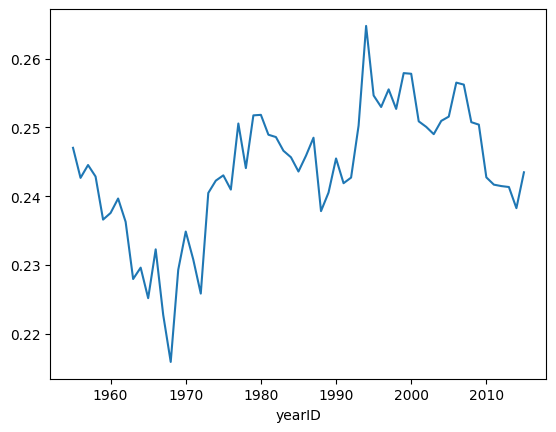

In [61]:
df.groupby('yearID')['AVG'].mean().sort_index().plot()

In [63]:
df.nlargest(10, 'AVG')[['yearID', 'teamID', 'AVG']]

,yearID,teamID,AVG
playerID,,,
cedence01,1985,SLN,0.434211
loretma01,2002,HOU,0.424242
haneyto01,1995,CHN,0.410959
clarkph02,1992,DET,0.407407
hazlebo01,1957,ML1,0.402985
davismi02,1982,OAK,0.400000
freedro01,1977,SLN,0.397590
reedje03,2004,SEA,0.396552
zimmery01,2005,WAS,0.396552


In [68]:
# Benjamin Thomas's change of AVG
df[df.index == 'zobribe01'][['nameGiven', 'yearID', 'AVG']].sort_values('yearID')

,nameGiven,yearID,AVG
playerID,,,
zobribe01,Benjamin Thomas,2006,0.224044
zobribe01,Benjamin Thomas,2007,0.154639
zobribe01,Benjamin Thomas,2008,0.252525
zobribe01,Benjamin Thomas,2009,0.297405
zobribe01,Benjamin Thomas,2010,0.238447
zobribe01,Benjamin Thomas,2011,0.268707
zobribe01,Benjamin Thomas,2012,0.269643
zobribe01,Benjamin Thomas,2013,0.274510
zobribe01,Benjamin Thomas,2014,0.271930


In [145]:
# 리그별(AL/NL) 평균 타율 비교
df.groupby('lgID')['AVG'].mean()

lgID
AL    0.249362
NL    0.239921
Name: AVG, dtype: float64

<Axes: xlabel='lgID', ylabel='AVG'>

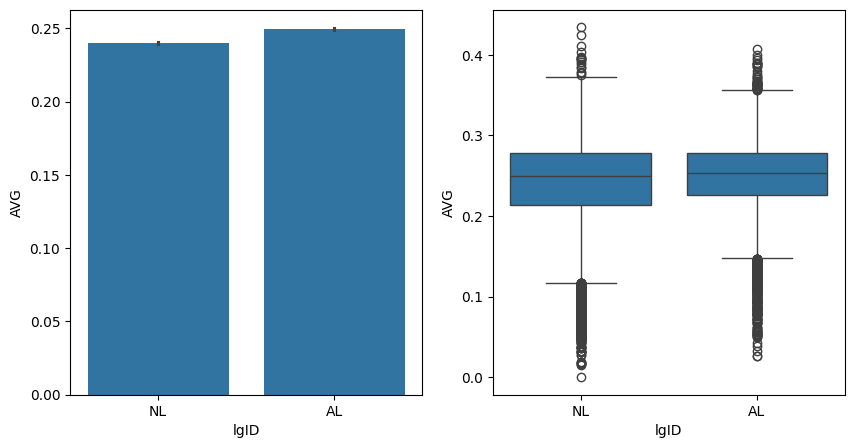

In [72]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(x="lgID", y="AVG", data=df)
plt.subplot(1,2,2)
sns.boxplot(x="lgID", y="AVG", data=df)

# Linear Regression Model

In [118]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [119]:
# select feature
features_names = ['H', 'R', '2B', '3B',
                  'HR', 'BB', 'SO', 'SB', 'height', 'weight']
X = df[features_names]
y = df['AVG']

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [121]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [122]:
lr.score(X_test, y_test)

0.4597902390951105

In [123]:
y_pred = lr.predict(X_test)

In [126]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test, y_pred)

0.03772407205272789

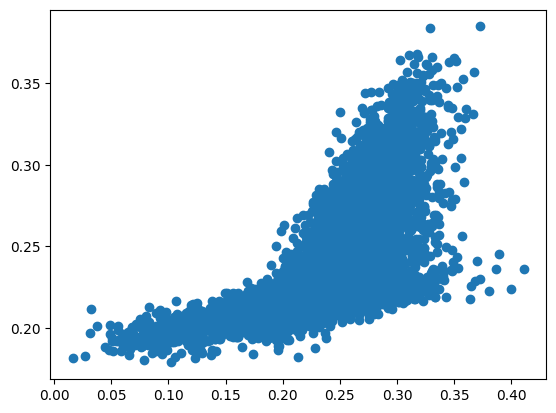

In [127]:
plt.scatter(y_test, y_pred)

# Predict is_300_hitter




In [112]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [133]:
# target column
df['is_300_hitter'] = (df['AVG'] >= 0.300).astype(int)

# select feature
features_names = ['H', 'R', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'height', 'weight']
# features_names = ['H', 'R', '2B', '3B', 'HR', 'BB', 'SO', 'SB']
X = df[features_names]
y = df['is_300_hitter']

In [134]:
# 분포 확인
df['is_300_hitter'].value_counts()

is_300_hitter
0    25575
1     3009
Name: count, dtype: int64

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234, stratify=y)

## Tree Model

In [136]:
# 모델 학습
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [137]:
print("Tree depth:", tree.get_depth())
print("Number of nodes:", tree.tree_.node_count)
print("Number of leaves:", tree.get_n_leaves())

Tree depth: 30
Number of nodes: 4103
Number of leaves: 2052


In [138]:
# 예측 및 평가
y_pred = tree.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5115
           1       0.38      0.41      0.40       602

    accuracy                           0.87      5717
   macro avg       0.66      0.67      0.66      5717
weighted avg       0.87      0.87      0.87      5717



In [139]:
from sklearn.metrics import accuracy_score, f1_score

for d in [3, 5, 7, 10, 15, 20, None]:
    tree = DecisionTreeClassifier(max_depth=d)
    tree.fit(X_train, y_train)
    pred = tree.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"max_depth={d}, acc={acc:.4f}, f1={f1:.4f}")

max_depth=3, acc=0.9124, f1=0.3552
max_depth=5, acc=0.9103, f1=0.3498
max_depth=7, acc=0.9097, f1=0.3333
max_depth=10, acc=0.9089, f1=0.4018
max_depth=15, acc=0.8930, f1=0.4205
max_depth=20, acc=0.8776, f1=0.4098
max_depth=None, acc=0.8688, f1=0.3971


In [140]:
# 모델 학습
tree = DecisionTreeClassifier(max_depth=10)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [89]:
from matplotlib import pyplot as plt

plt.figure(figsize=(100,100))
plot_tree(
    tree,
    class_names=["YES", "NO"],
    feature_names=features_names,
    filled=True,
)
plt.show()

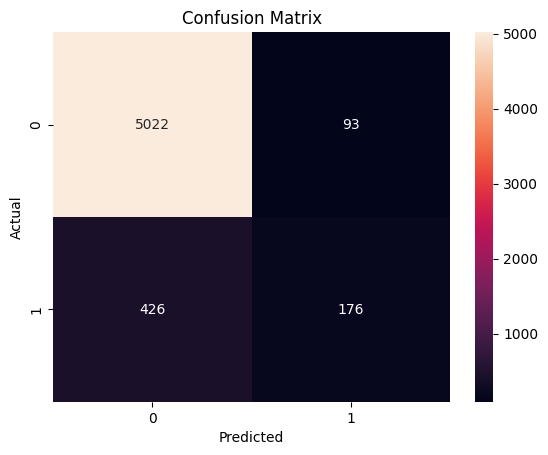

In [141]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = tree.predict(X_test)
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [142]:
tree.feature_importances_

array([0.53974714, 0.03369508, 0.04589165, 0.0231126 , 0.06811656,
       0.07892646, 0.12678714, 0.02702374, 0.01633418, 0.04036545])

In [91]:
from sklearn.metrics import roc_auc_score

proba = tree.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, proba)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.7401


In [190]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree, X, y, cv=5)
print(f"Mean CV accuracy: {scores.mean():.4f}")

Mean CV accuracy: 0.9527


In [191]:
# 모델 학습
model = RandomForestClassifier(class_weight='balanced', n_estimators=500, max_depth=15)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5115
           1       0.95      0.69      0.80       602

    accuracy                           0.96      5717
   macro avg       0.96      0.84      0.89      5717
weighted avg       0.96      0.96      0.96      5717



In [192]:
# 예측 및 평가
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5115
           1       0.95      0.69      0.80       602

    accuracy                           0.96      5717
   macro avg       0.96      0.84      0.89      5717
weighted avg       0.96      0.96      0.96      5717



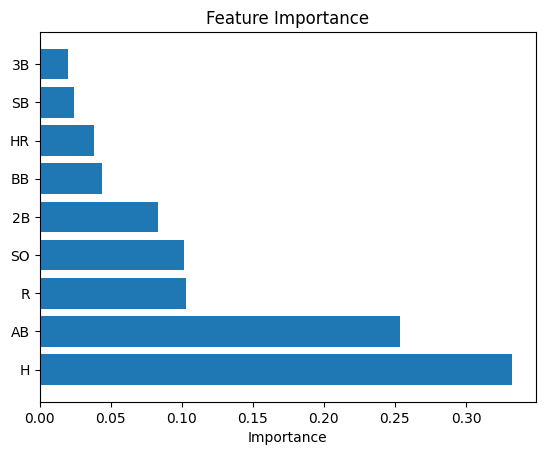

In [196]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
feat_names = X.columns
feat_imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
# plt.gca().invert_yaxis()
plt.show()

| 항목             | 내용                                                   |
| -------------- | ---------------------------------------------------- |
| 🎯 예측 목표       | `타율이 0.300 이상인지 여부` (이진 분류)                          |
| 🔢 타겟 (`y`)    | `is_300_hitter` (1: 우수 타자, 0: 보통 타자)                 |
| 🧩 입력 피쳐 (`X`) | `AB`, `H`, `HR`, `BB`, `SO`, `SB`, `2B`, `3B`, `R` 등 |
| 🤖 사용 모델       | RandomForestClassifier                    |
| 📈 평가 결과       | Accuracy 96%, Precision 0.97 (우수 타자 예측), Recall 0.75 |


# Fielding

In [15]:
fielding = pd.read_csv("Fielding.csv")
df = pd.merge(df, fielding[['playerID', 'yearID', 'POS']], on=[
              'playerID', 'yearID'])

FileNotFoundError: [Errno 2] No such file or directory: 'Fielding.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441026 entries, 0 to 441025
Data columns (total 48 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   playerID      441026 non-null  object 
 1   yearID        441026 non-null  int64  
 2   stint         441026 non-null  int64  
 3   teamID        441026 non-null  object 
 4   lgID          437074 non-null  object 
 5   G             441026 non-null  int64  
 6   AB            441026 non-null  float64
 7   R             441026 non-null  float64
 8   H             441026 non-null  float64
 9   2B            441026 non-null  float64
 10  3B            441026 non-null  float64
 11  HR            441026 non-null  float64
 12  RBI           437886 non-null  float64
 13  SB            434500 non-null  float64
 14  CS            370212 non-null  float64
 15  BB            441026 non-null  float64
 16  SO            410639 non-null  float64
 17  IBB           343713 non-null  float64
 18  HBP 

<Axes: xlabel='POS_x', ylabel='AVG'>

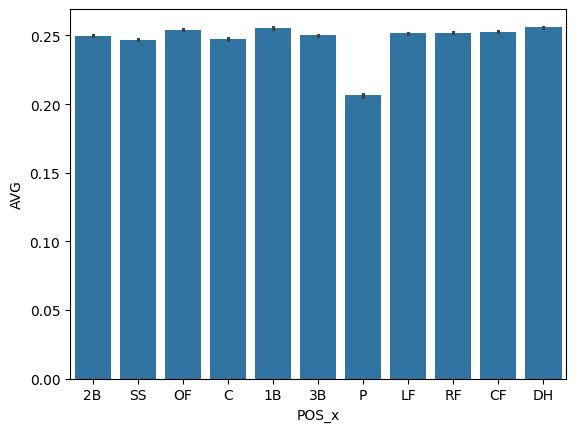

In [ ]:
sns.barplot(x='POS_x', y='AVG', data=df)